# 🔬 IMPLEMENTASI SIKLUS MACHINE LEARNING LENGKAP (8 TAHAPAN)
### **Studi Kasus: Analisis Komparasi QDA vs Algoritma Modern untuk Prediksi Risiko Diabetes**
**Dokumen ini disusun sebagai panduan implementasi komprehensif dari pengumpulan data hingga penyimpanan model (Model Persistence).**

---

## ⚙️ PERSIAPAN LINGKUNGAN KERJA (ENVIRONMENT SETUP)
Pada tahap ini, kita mengimpor seluruh pustaka (*library*) yang diperlukan untuk analisis data, visualisasi, penyeleksian fitur, pemodelan, hingga penyimpanan biner model.

In [1]:
# Pustaka Manipulasi Data & Sistem
import pandas as pd
import numpy as np
import time
import datetime
import os
import pickle
import warnings

# Pustaka Visualisasi Grafis
import matplotlib.pyplot as plt
import seaborn as sns

# Pustaka Preprocessing & Feature Selection
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

# Pustaka Algoritma Machine Learning Pembanding
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import RidgeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import BaggingClassifier
from catboost import CatBoostClassifier  # Pastikan sudah: !pip install catboost

# Pustaka Evaluasi Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# Pengaturan Jupyter & Pengabaian Warning
%matplotlib inline
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')
print("✅ Semua library berhasil di-import!")

✅ Semua library berhasil di-import!


---
## 📥 TAHAP 1: PENGUMPULAN DATA (DATA COLLECTION)
Proses memuat dataset medis mentah ke dalam lingkungan kerja. Pastikan file `diabetes_data_upload.csv` berada dalam direktori yang sama dengan notebook ini.

In [2]:
# Tentukan path file dataset
file_path = 'diabetes_data_upload.csv'

# Membaca dataset menggunakan pandas
df_raw = pd.read_csv(file_path)
baris_awal, kolom_awal = df_raw.shape

print(f"=== TAHAP 1: DATA COLLECTION SUCCESS ===")
print(f"Dimensi Dataset Mentah: {baris_awal} baris dan {kolom_awal} kolom.\n")
print("Menampilkan 5 Baris Pertama Data Mentah:")
display(df_raw.head())

=== TAHAP 1: DATA COLLECTION SUCCESS ===
Dimensi Dataset Mentah: 520 baris dan 17 kolom.

Menampilkan 5 Baris Pertama Data Mentah:


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


---
## 🧹 TAHAP 2: PERSIAPAN & PEMBERSIHAN DATA (DATA PREPROCESSING)
Melakukan pembersihan data dari baris duplikat, mendeteksi nilai yang hilang (*missing values*), serta melakukan analisis outlier pada variabel numerik (`Age`).

=== TAHAP 2: DATA PREPROCESSING SUMMARY ===
1. Data Duplikat Dihapus : 269 baris
2. Missing Values        : 0 sel
3. Outlier Usia (Medis)  : 1 sampel (dipertahankan demi variasi fisiologis)
4. Total Data Bersih     : 251 baris



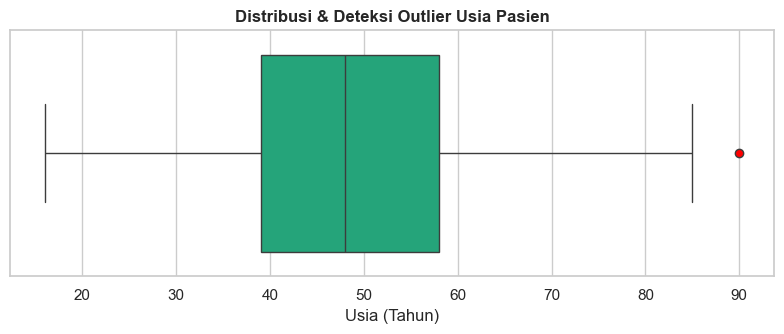

In [3]:
# 1. Deteksi & Hapus Data Duplikat
jumlah_duplikat = df_raw.duplicated().sum()
df_cleaned = df_raw.drop_duplicates()
df_cleaned.columns = df_cleaned.columns.str.strip()  # Membersihkan spasi pada nama kolom
baris_akhir, kolom_akhir = df_cleaned.shape

# 2. Deteksi Missing Values
missing_val = df_cleaned.isnull().sum().sum()

# 3. Deteksi Outlier pada Variabel Usia (Age) Menggunakan Metode IQR
outlier_count = 0
if 'Age' in df_cleaned.columns:
    Q1 = df_cleaned['Age'].quantile(0.25)
    Q3 = df_cleaned['Age'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_cleaned[(df_cleaned['Age'] < lower_bound) | (df_cleaned['Age'] > upper_bound)]
    outlier_count = len(outliers)

print(f"=== TAHAP 2: DATA PREPROCESSING SUMMARY ===")
print(f"1. Data Duplikat Dihapus : {jumlah_duplikat} baris")
print(f"2. Missing Values        : {missing_val} sel")
print(f"3. Outlier Usia (Medis)  : {outlier_count} sampel (dipertahankan demi variasi fisiologis)")
print(f"4. Total Data Bersih     : {baris_akhir} baris\n")

# Visualisasi Boxplot untuk Deteksi Outlier
if 'Age' in df_cleaned.columns:
    plt.figure(figsize=(8, 3.5))
    sns.boxplot(x=df_cleaned['Age'], color='#10b981', flierprops=dict(markerfacecolor='red', marker='o'))
    plt.title('Distribusi & Deteksi Outlier Usia Pasien', fontsize=12, fontweight='bold')
    plt.xlabel('Usia (Tahun)')
    plt.tight_layout()
    plt.show()

---
## ⚙️ TAHAP 3: REKAYASA FITUR (FEATURE ENGINEERING)
Mengubah fitur-fitur kategorikal bertipe teks (`Yes`/`No`, `Male`/`Female`) menjadi representasi angka skalar/biner (0 dan 1) menggunakan `LabelEncoder` agar dapat diproses oleh fungsi matematis algoritma ML.

=== TAHAP 3: FEATURE ENGINEERING SUCCESS ===
Menampilkan 5 Baris Pertama Data Hasil Encoding:


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


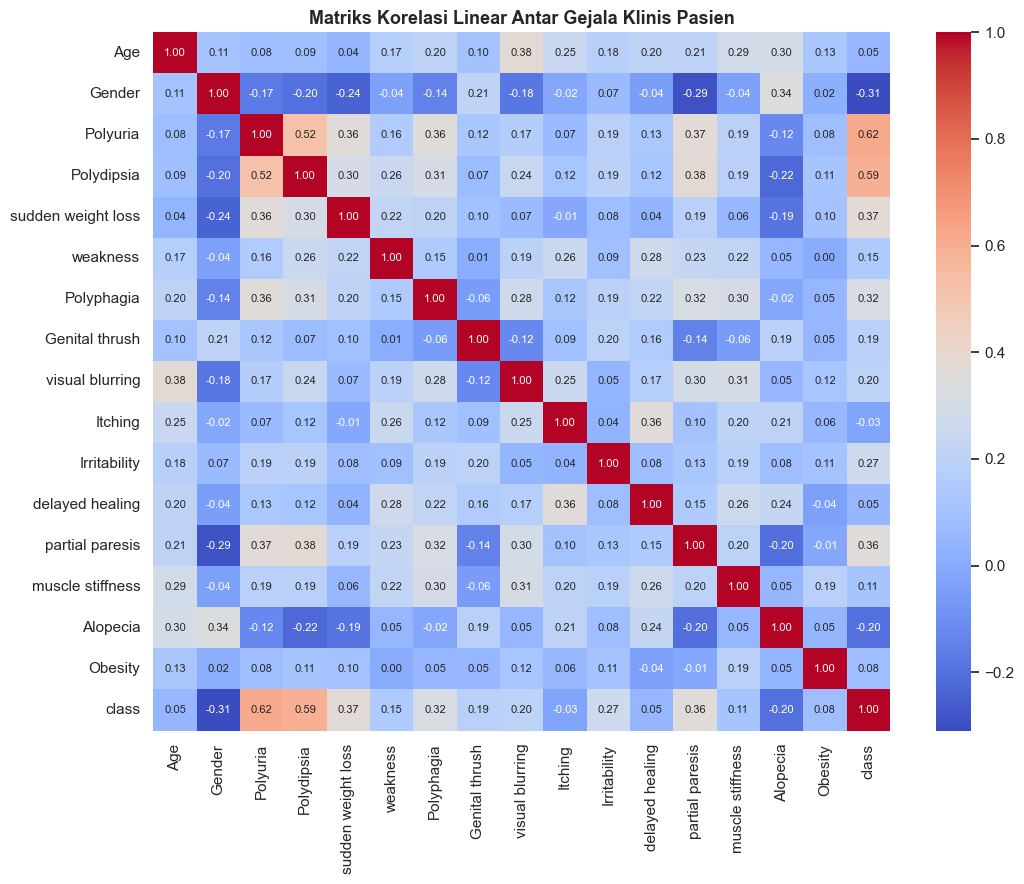

In [4]:
df_encoded = df_cleaned.copy()
le = LabelEncoder()

# Proses Transformasi Teks ke Numerik
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

print("=== TAHAP 3: FEATURE ENGINEERING SUCCESS ===")
print("Menampilkan 5 Baris Pertama Data Hasil Encoding:")
display(df_encoded.head())

# Visualisasi Matriks Korelasi Global
plt.figure(figsize=(11, 9))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True, annot_kws=dict(size=8))
plt.title('Matriks Korelasi Linear Antar Gejala Klinis Pasien', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🎯 TAHAP 3B: SELEKSI FITUR (FEATURE SELECTION)
Menggunakan **Mutual Information (Information Gain)** untuk mengukur seberapa kuat kontribusi dan informasi yang diberikan oleh masing-masing gejala klinis terhadap keputusan label target (`class`). Kita hanya akan memilih **Top 10 Fitur Terbaik**.

=== TAHAP 3B: HASIL PERINGKAT SELEKSI FITUR ===


,Skor Pengaruh (Information Gain)
Polyuria,0.250826
Polydipsia,0.208278
partial paresis,0.091014
sudden weight loss,0.052280
Itching,0.051494
Alopecia,0.043630
Polyphagia,0.041088
Gender,0.033766
Obesity,0.033521
weakness,0.021282


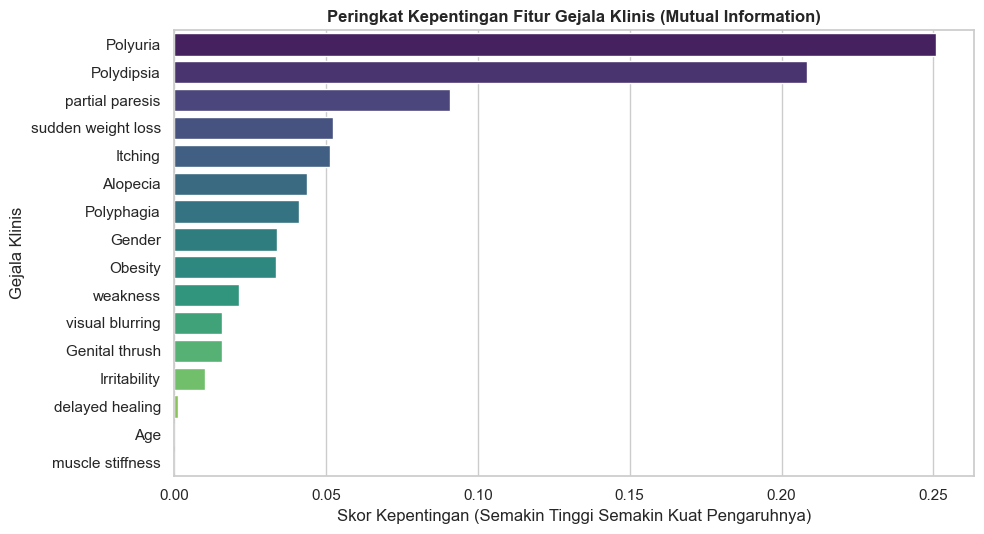


💡 KESIMPULAN SELEKSI FITUR:
Sistem mereduksi dimensi dan menetapkan 10 fitur teratas ini: ['Polyuria', 'Polydipsia', 'partial paresis', 'sudden weight loss', 'Itching', 'Alopecia', 'Polyphagia', 'Gender', 'Obesity', 'weakness']


In [5]:
# Menentukan kolom target
target_column = 'class' if 'class' in df_encoded.columns else df_encoded.columns[-1]
X_temp = df_encoded.drop(target_column, axis=1)
y_temp = df_encoded[target_column]

# Menghitung skor Information Gain
mi_scores = mutual_info_classif(X_temp, y_temp, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X_temp.columns).sort_values(ascending=False)

print("=== TAHAP 3B: HASIL PERINGKAT SELEKSI FITUR ===")
display(pd.DataFrame(mi_scores_series, columns=['Skor Pengaruh (Information Gain)']))

# Visualisasi Peringkat Fitur
plt.figure(figsize=(10, 5.5))
sns.barplot(x=mi_scores_series.values, y=mi_scores_series.index, palette='viridis')
plt.title('Peringkat Kepentingan Fitur Gejala Klinis (Mutual Information)', fontsize=12, fontweight='bold')
plt.xlabel('Skor Kepentingan (Semakin Tinggi Semakin Kuat Pengaruhnya)')
plt.ylabel('Gejala Klinis')
plt.tight_layout()
plt.show()

# MENYARING DATASET: Mengambil Top 10 Fitur Terbaik
jumlah_fitur_dipilih = 10
fitur_terpilih = mi_scores_series.head(jumlah_fitur_dipilih).index.tolist()
X_selected = X_temp[fitur_terpilih]

print(f"\n💡 KESIMPULAN SELEKSI FITUR:")
print(f"Sistem mereduksi dimensi dan menetapkan {jumlah_fitur_dipilih} fitur teratas ini: {fitur_terpilih}")

---
## 🧠 TAHAP 4: PEMILIHAN MODEL & PEMBAGIAN DATA (MODEL SELECTION & SPLIT)
Membagi dataset yang telah diseleksi menjadi **Data Latih (80%)** untuk pembangunan model, dan **Data Uji (20%)** untuk pengujian objektif performa.

In [6]:
# Menggunakan X yang sudah diseleksi filternya
X = X_selected
y = y_temp

# Melakukan Split secara objektif
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mendefinisikan 5 Arsitektur Model Komparatif
models = {
    "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
    "CatBoost Classifier": CatBoostClassifier(verbose=0, random_state=42),
    "Ridge Classifier": RidgeClassifier(random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "Bagging Classifier": BaggingClassifier(random_state=42)
}

print(f"=== TAHAP 4: PEMBAGIAN DATA SELESAI ===")
print(f"-> Dimensi Data Latih (Training Set - 80%): {X_train.shape[0]} Baris, {X_train.shape[1]} Fitur Terpilih")
print(f"-> Dimensi Data Uji (Testing Set - 20%)  : {X_test.shape[0]} Baris, {X_test.shape[1]} Fitur Terpilih")

=== TAHAP 4: PEMBAGIAN DATA SELESAI ===
-> Dimensi Data Latih (Training Set - 80%): 200 Baris, 10 Fitur Terpilih
-> Dimensi Data Uji (Testing Set - 20%)  : 51 Baris, 10 Fitur Terpilih


---
## ⏳ TAHAP 5: PELATIHAN MODEL (MODEL TRAINING)
Sistem melakukan proses *fitting*/pelatihan secara paralel terhadap kelima algoritma menggunakan data latih.

In [7]:
all_models = {}

print("=== TAHAP 5: PELATIHAN MULTI-ALGORITMA LOG ===")
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)  # Proses training
    all_models[name] = model
    duration = time.time() - start_time
    print(f"✅ Model {name:<35} Berhasil Dilatih dalam {duration:.4f} detik.")

=== TAHAP 5: PELATIHAN MULTI-ALGORITMA LOG ===
✅ Model Quadratic Discriminant Analysis     Berhasil Dilatih dalam 0.0106 detik.
✅ Model CatBoost Classifier                 Berhasil Dilatih dalam 2.6090 detik.
✅ Model Ridge Classifier                    Berhasil Dilatih dalam 0.0095 detik.
✅ Model Gaussian Naive Bayes                Berhasil Dilatih dalam 0.0033 detik.
✅ Model Bagging Classifier                  Berhasil Dilatih dalam 0.0364 detik.


---
## 📈 TAHAP 6: EVALUASI PERFORMA MODEL (METRIK GLOBAL & CONFUSION MATRIX)
Mengukur kualitas prediksi kelima model menggunakan metrik standar data science: Akurasi, Presisi, dan Recall (Sensitivitas), diikuti visualisasi grafik Confusion Matrix.

=== TAHAP 6A: TABEL RINGKASAN PERFORMA GLOBAL ===


,Akurasi Global,Presisi,Recall (Sensitivitas)
Quadratic Discriminant Analysis,86.3%,86.8%,94.3%
CatBoost Classifier,90.2%,89.5%,97.1%
Ridge Classifier,82.4%,90.6%,82.9%
Gaussian Naive Bayes,86.3%,91.2%,88.6%
Bagging Classifier,88.2%,89.2%,94.3%


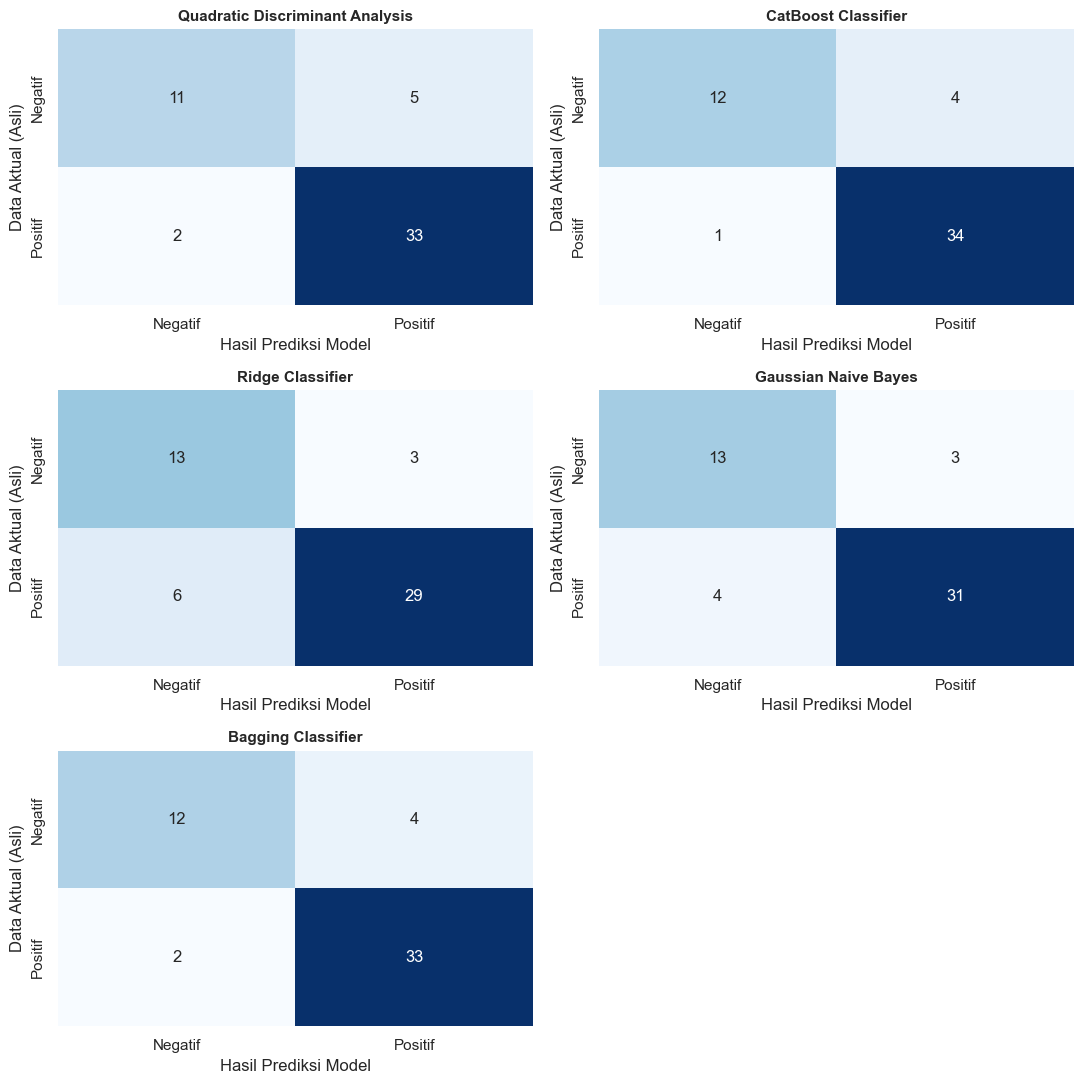

In [8]:
all_metrics = {}
all_confusion_matrices = {}
all_predictions = {}

for name, model in all_models.items():
    y_pred = model.predict(X_test)
    all_predictions[name] = y_pred  # Menyimpan hasil tebakan
    
    # Menghitung metrik evaluasi
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    all_metrics[name] = {
        "Akurasi Global": f"{acc * 100:.1f}%",
        "Presisi": f"{prec * 100:.1f}%",
        "Recall (Sensitivitas)": f"{rec * 100:.1f}%"
    }
    all_confusion_matrices[name] = confusion_matrix(y_test, y_pred)

print("=== TAHAP 6A: TABEL RINGKASAN PERFORMA GLOBAL ===")
display(pd.DataFrame(all_metrics).T)

# Visualisasi Plural Confusion Matrix
fig, axes = plt.subplots(3, 2, figsize=(11, 11))
axes = axes.ravel()

for idx, (name, cm) in enumerate(all_confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'], ax=axes[idx])
    axes[idx].set_title(name, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Data Aktual (Asli)')
    axes[idx].set_xlabel('Hasil Prediksi Model')

# Menghapus sub-plot terakhir yang kosong karena kita hanya punya 5 model
if len(all_confusion_matrices) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### 📋 TAHAP 6 LANJUTAN: DETAIL CLASSIFICATION REPORT & TABEL PREDIKSI AKTUAL
Menampilkan laporan performa mendalam per kelas (F1-score & Support) serta menyajikan tabel visual perbandingan antara Jawaban Aktual dan hasil tebakan kelima model AI secara baris-demi-baris data uji.

In [9]:
print("==========================================================")
print(" 📊 DETAIL CLASSIFICATION REPORT PER KELAS MODEL AI")
print("==========================================================\n")

for name in all_models.keys():
    print(f"🔸 Hasil Klasifikasi Detail : {name}")
    print("-" * 60)
    print(classification_report(y_test, all_predictions[name], target_names=['Negatif (0)', 'Positif (1)']))
    print("\n")

print("==========================================================")
print(" 📋 TABEL SAMPEL HASIL KLASIFIKASI (AKTUAL VS PREDIKSI)")
print("==========================================================\n")

# Menyusun dataframe perbandingan hasil uji
df_hasil_klasifikasi = X_test.copy()
df_hasil_klasifikasi.insert(0, 'KUNCI JAWABAN (AKTUAL)', y_test)

for name in all_models.keys():
    df_hasil_klasifikasi[f'Prediksi {name}'] = all_predictions[name]

print("Menampilkan 10 sampel baris teratas dari total", len(y_test), "data uji:")
display(df_hasil_klasifikasi.head(10))

 📊 DETAIL CLASSIFICATION REPORT PER KELAS MODEL AI

🔸 Hasil Klasifikasi Detail : Quadratic Discriminant Analysis
------------------------------------------------------------
              precision    recall  f1-score   support

 Negatif (0)       0.85      0.69      0.76        16
 Positif (1)       0.87      0.94      0.90        35

    accuracy                           0.86        51
   macro avg       0.86      0.82      0.83        51
weighted avg       0.86      0.86      0.86        51



🔸 Hasil Klasifikasi Detail : CatBoost Classifier
------------------------------------------------------------
              precision    recall  f1-score   support

 Negatif (0)       0.92      0.75      0.83        16
 Positif (1)       0.89      0.97      0.93        35

    accuracy                           0.90        51
   macro avg       0.91      0.86      0.88        51
weighted avg       0.90      0.90      0.90        51



🔸 Hasil Klasifikasi Detail : Ridge Classifier
------------

,KUNCI JAWABAN (AKTUAL),Polyuria,Polydipsia,partial paresis,sudden weight loss,Itching,Alopecia,Polyphagia,Gender,Obesity,weakness,Prediksi Quadratic Discriminant Analysis,Prediksi CatBoost Classifier,Prediksi Ridge Classifier,Prediksi Gaussian Naive Bayes,Prediksi Bagging Classifier
156,1,1,1,1,1,0,0,0,1,0,1,1,1,1,1,1
6,1,1,1,1,0,0,0,1,1,0,1,1,1,1,1,1
197,1,1,0,0,0,0,1,1,0,0,0,1,1,1,1,1
60,1,1,1,1,0,1,0,1,0,0,1,1,1,1,1,1
114,1,1,0,1,1,1,0,0,0,0,0,1,1,1,1,1
215,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0
232,0,0,1,0,0,1,1,1,1,0,1,1,1,1,1,1
517,1,1,1,1,1,0,0,1,0,1,1,1,1,1,1,1
9,1,0,1,0,1,1,1,1,1,0,1,1,1,1,1,1
119,1,1,1,0,0,0,0,0,0,0,1,1,1,1,1,1


---
## 🚀 TAHAP 7: PENERAPAN SISTEM (DEPLOYMENT SIMULATION PASIEN BARU)
Simulasi penggunaan operasional model medis di lapangan. Pengguna memasukkan data gejala pasien baru, dan sistem melakukan penyaringan otomatis berdasarkan **10 Fitur Terpilih** serta mengambil keputusan final lewat metode **Konsensus/Voting Mayoritas**.

In [10]:
print("=== TAHAP 7: SIMULASI PENERAPAN KONSOL MEDIS ===\n")

# 1. Input Gejala Pasien (HANYA MENGGUNAKAN 8 FITUR TERBAIK)
data_pasien_baru = {
    'Polyuria': 'Yes',             # Sering buang air kecil?
    'Polydipsia': 'Yes',           # Sering merasa haus?
    'partial paresis': 'No',       # Kelumpuhan sebagian otot?
    'sudden weight loss': 'No',    # Berat badan turun drastis?
    'Itching': 'Yes',              # Kulit gatal-gatal?
    'Alopecia': 'Yes',             # Rambut rontok parah?
    'Polyphagia': 'No',            # Sering merasa lapar?
    'Gender': 'Male'               # Jenis Kelamin (Male/Female)
}

# Dictionary Mapping Sesuai Hasil Encoding Tahap 3
mapping = {"No": 0, "Yes": 1, "Female": 0, "Male": 1}

# 2. Proses Mapping yang AMAN (Anti KeyError)
input_siap_prediksi = {}
for kolom in fitur_terpilih:  
    # Menggunakan .get() agar jika ada nama kolom yang sedikit meleset, 
    # sistem tidak error dan otomatis mengisinya dengan 'No' (nilai aman)
    nilai_mentah = data_pasien_baru.get(kolom, 'No')
    
    # Lakukan mapping menjadi 0 dan 1
    if nilai_mentah in mapping:
        input_siap_prediksi[kolom] = mapping[nilai_mentah]
    else:
        input_siap_prediksi[kolom] = nilai_mentah

# Konversi ke Format DataFrame Pandas
df_input_pasien = pd.DataFrame([input_siap_prediksi], columns=fitur_terpilih)
print("Data 8 Gejala Klinis Pasien Yang Masuk Ke Sistem Komputasi Model:")
display(df_input_pasien)

print("\n=== HASIL DIAGNOSIS SISTEM AI ===")

# 3. Eksekusi Prediksi Menggunakan SATU Model Utama (QDA)
model_utama = all_models["Quadratic Discriminant Analysis"]
pred = model_utama.predict(df_input_pasien)[0]

print("-" * 65)
if pred == 1:
    print("🚨 KESIMPULAN AKHIR: PASIEN DIPREDIKSI POSITIF (BERISIKO DIABETES).")
    print("Sangat direkomendasikan untuk segera melakukan uji klinis gula darah lanjutan di laboratorium.")
else:
    print("🎉 KESIMPULAN AKHIR: PASIEN DIPREDIKSI NEGATIF (AMAN DARI RISIKO DIABETES).")
    print("Pertahankan pola makan dan gaya hidup sehat.")
print("-" * 65)

=== TAHAP 7: SIMULASI PENERAPAN KONSOL MEDIS ===

Data 8 Gejala Klinis Pasien Yang Masuk Ke Sistem Komputasi Model:


,Polyuria,Polydipsia,partial paresis,sudden weight loss,Itching,Alopecia,Polyphagia,Gender,Obesity,weakness
0,1,1,0,0,1,1,0,1,0,0



=== HASIL DIAGNOSIS SISTEM AI ===
-----------------------------------------------------------------
🚨 KESIMPULAN AKHIR: PASIEN DIPREDIKSI POSITIF (BERISIKO DIABETES).
Sangat direkomendasikan untuk segera melakukan uji klinis gula darah lanjutan di laboratorium.
-----------------------------------------------------------------


---
## 💾 TAHAP 8: PEMELIHARAAN & PERSISTENSI MODEL (MODEL PERSISTENCE)
Membekukan/menyimpan objek model biner yang sudah matang dilatih ke dalam disk lokal berformat file `.pkl` (Pickle) agar aplikasi web (seperti Streamlit) dapat langsung menggunakannya kembali tanpa melatih ulang.

In [11]:
# Membuat direktori folder penyimpanan khusus
folder_output = 'saved_models'
os.makedirs(folder_output, exist_ok=True)

print("=== TAHAP 8: EXPORTING MODEL TO DISK (PICKLE) ===\n")
for name, model in all_models.items():
    # Normalisasi penamaan file
    clean_filename = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    file_path = os.path.join(folder_output, f"{clean_filename}.pkl")
    
    # Eksekusi serialisasi model
    with open(file_path, 'wb') as file:
        pickle.dump(model, file)
        
    print(f"💾 Model {name:<35} Berhasil Diexport -> {file_path}")

print(f"\n✅ SELURUH SIKLUS MACHINE LEARNING SELESAI PADA: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("File biner .pkl siap diintegrasikan pada arsitektur web produksi app.py Streamlit!")

=== TAHAP 8: EXPORTING MODEL TO DISK (PICKLE) ===

💾 Model Quadratic Discriminant Analysis     Berhasil Diexport -> saved_models\quadratic_discriminant_analysis.pkl
💾 Model CatBoost Classifier                 Berhasil Diexport -> saved_models\catboost_classifier.pkl
💾 Model Ridge Classifier                    Berhasil Diexport -> saved_models\ridge_classifier.pkl
💾 Model Gaussian Naive Bayes                Berhasil Diexport -> saved_models\gaussian_naive_bayes.pkl
💾 Model Bagging Classifier                  Berhasil Diexport -> saved_models\bagging_classifier.pkl

✅ SELURUH SIKLUS MACHINE LEARNING SELESAI PADA: 2026-05-31 11:05:03
File biner .pkl siap diintegrasikan pada arsitektur web produksi app.py Streamlit!


 🥇 PERINGKAT FITUR (INFORMATION GAIN)


,Skor Pengaruh (Information Gain)
Polyuria,0.250826
Polydipsia,0.208278
partial paresis,0.091014
sudden weight loss,0.052280
Itching,0.051494
Alopecia,0.043630
Polyphagia,0.041088
Gender,0.033766
Obesity,0.033521
weakness,0.021282


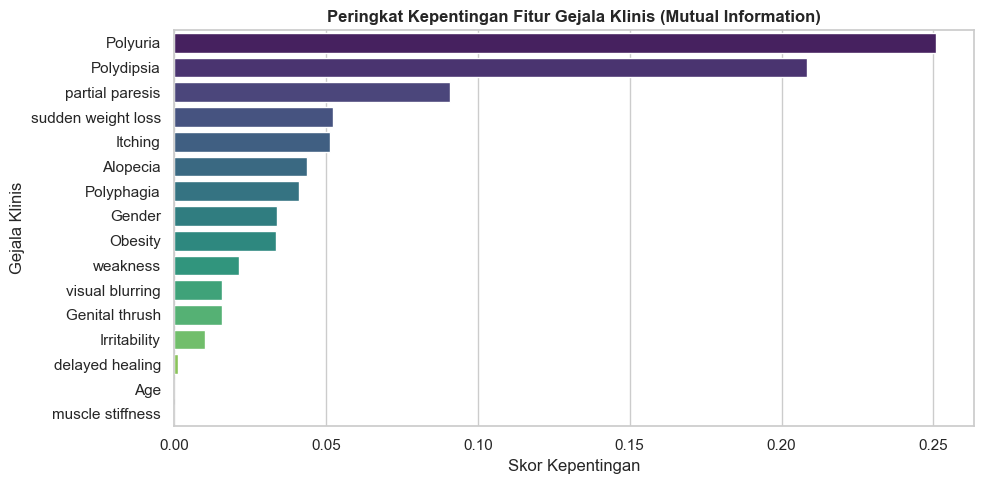


💡 KESIMPULAN SELEKSI FITUR:
Sistem menetapkan 8 fitur teratas ini: ['Polyuria', 'Polydipsia', 'partial paresis', 'sudden weight loss', 'Itching', 'Alopecia', 'Polyphagia', 'Gender']

 🔍 PREVIEW DATA (FITUR X) YANG SUDAH DISELEKSI & BERSIH
Dimensi Data Saat Ini: 251 Baris, 8 Kolom Fitur

Menampilkan 5 Baris Pertama Data Hasil Seleksi:


,Polyuria,Polydipsia,partial paresis,sudden weight loss,Itching,Alopecia,Polyphagia,Gender
0,0,1,0,0,1,1,0,1
1,0,0,1,0,0,1,0,1
2,1,0,0,0,1,1,1,1
3,0,0,0,1,1,0,1,1
4,1,1,1,1,1,1,1,1


In [13]:
# =====================================================================
# 🎯 TAHAP 3B: SELEKSI FITUR (MUTUAL INFORMATION)
# =====================================================================

# 1. Menentukan kolom target
target_column = 'class' if 'class' in df_encoded.columns else df_encoded.columns[-1]
X_temp = df_encoded.drop(target_column, axis=1)
y_temp = df_encoded[target_column]

# 2. Menghitung skor Information Gain
mi_scores = mutual_info_classif(X_temp, y_temp, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X_temp.columns).sort_values(ascending=False)

print("==========================================================")
print(" 🥇 PERINGKAT FITUR (INFORMATION GAIN)")
print("==========================================================")
display(pd.DataFrame(mi_scores_series, columns=['Skor Pengaruh (Information Gain)']).head(10))

# 3. Visualisasi Peringkat Fitur
plt.figure(figsize=(10, 5))
sns.barplot(x=mi_scores_series.values, y=mi_scores_series.index, palette='viridis')
plt.title('Peringkat Kepentingan Fitur Gejala Klinis (Mutual Information)', fontsize=12, fontweight='bold')
plt.xlabel('Skor Kepentingan')
plt.ylabel('Gejala Klinis')
plt.tight_layout()
plt.show()

# 4. MENYARING DATASET: Mengambil Top 8 Fitur Terbaik (Sesuai Streamlit)
jumlah_fitur_dipilih = 8
fitur_terpilih = mi_scores_series.head(jumlah_fitur_dipilih).index.tolist()
X_selected = X_temp[fitur_terpilih]

print(f"\n💡 KESIMPULAN SELEKSI FITUR:")
print(f"Sistem menetapkan {jumlah_fitur_dipilih} fitur teratas ini: {fitur_terpilih}")

print("\n==========================================================")
print(" 🔍 PREVIEW DATA (FITUR X) YANG SUDAH DISELEKSI & BERSIH")
print("==========================================================")
print(f"Dimensi Data Saat Ini: {X_selected.shape[0]} Baris, {X_selected.shape[1]} Kolom Fitur\n")
print("Menampilkan 5 Baris Pertama Data Hasil Seleksi:")
display(X_selected.head())